In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

In [2]:
import numpy as np
from collections import deque
import matplotlib.pyplot as plt

In [3]:
import gymnasium as gym
import flappy_bird_gymnasium

# Specify vector observation mode
env_id = "FlappyBird-v0"
env = gym.make(env_id, render_mode="rgb_array", use_lidar=False)
eval_env = gym.make(env_id, render_mode="rgb_array", use_lidar=False)

s_size = env.observation_space.shape[0]
a_size = env.action_space.n

In [4]:
print(f"State space size: {s_size}")
print(f"Action space size: {a_size}")

State space size: 12
Action space size: 2


In [5]:
print("_____OBSERVATION SPACE_____ \n")
print("The State Space is: ", s_size)
print("Sample observation", env.observation_space.sample())  # Get a random observation

_____OBSERVATION SPACE_____ 

The State Space is:  12
Sample observation [ 0.18522427 -0.57181572 -0.2113148  -0.91047199  0.54881806 -0.14997764
  0.756932   -0.5335052   0.48635949  0.6987764  -0.596742    0.85066876]


In [6]:
print("\n _____ACTION SPACE_____ \n")
print("The Action Space is: ", a_size)
print("Action Space Sample", env.action_space.sample())  # Take a random action


 _____ACTION SPACE_____ 

The Action Space is:  2
Action Space Sample 0


### Observation space:

**Pipe Tracking (Indices 0–8)**
* **Last Pipe Passed:** Horizontal distance (`0`), top pipe Y-position (`1`), and bottom pipe Y-position (`2`).
* **Next Upcoming Pipe:** Horizontal distance (`3`), top pipe Y-position (`4`), and bottom pipe Y-position (`5`).
* **Second Upcoming Pipe:** Horizontal distance (`6`), top pipe Y-position (`7`), and bottom pipe Y-position (`8`).

**Player State (Indices 9–11)**
* **Vertical Position:** The bird's current Y-coordinate (`9`).
* **Vertical Velocity:** Current movement speed/acceleration along the Y-axis (`10`).
* **Rotation:** Current tilt angle of the bird (`11`).

In [7]:
class Policy(nn.Module):
    def __init__(self, s_size, a_size, h_size):
        super(Policy, self).__init__()
        self.fc1 = nn.Linear(s_size, h_size)
        self.fc2 = nn.Linear(h_size, h_size * 2)
        self.fc3 = nn.Linear(h_size * 2, a_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return F.softmax(x, dim=1)

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        m = Categorical(probs)
        action = m.sample()
        return action.item(), m.log_prob(action)

### Define the hyperparameters
Because this environment is more complex.  
Especially for the hidden size, we need more neurons.

In [21]:
hyperparameters = {
    "h_size": 64,
    "n_training_episodes": 50000,
    "n_evaluation_episodes": 10,
    "max_t": 10000,
    "gamma": 0.99,
    "lr": 1e-4,
    "env_id": env_id,
    "state_space": int(s_size),
    "action_space": int(a_size),
}

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [10]:
print(device)

cuda:0


In [22]:
# Create policy and place it to the device
# torch.manual_seed(50)
policy = Policy(
    hyperparameters["state_space"],
    hyperparameters["action_space"],
    hyperparameters["h_size"],
).to(device)

optimizer = optim.Adam(policy.parameters(), lr=hyperparameters["lr"])

In [12]:
def reinforce(policy, optimizer, n_training_episodes, max_t, gamma, print_every):
    scores_deque = deque(maxlen=100)
    scores = []

    for i_episode in range(1, n_training_episodes + 1):
        saved_log_probs = []
        rewards = []
        state, _ = env.reset()

        # Step 1: Collect trajectory
        for t in range(max_t):
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            rewards.append(reward)
            if done:
                break

        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Step 2: Compute discounted returns (G_t) starting from end of episode
        returns = deque(maxlen=max_t)
        n_steps = len(rewards)

        for t in range(n_steps)[::-1]:
            disc_return_t = returns[0] if len(returns) > 0 else 0
            returns.appendleft(gamma * disc_return_t + rewards[t])

        # Normalize returns for numeric stability
        eps = np.finfo(np.float32).eps.item()
        returns = torch.tensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + eps)

        # Step 3: Compute policy loss
        policy_loss = []
        for log_prob, disc_return in zip(saved_log_probs, returns):
            policy_loss.append(-log_prob * disc_return)
        policy_loss = torch.cat(policy_loss).sum()

        # Step 4: Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if i_episode % print_every == 0:
            print(f"Episode {i_episode}\tAverage Score (Last 100): {np.mean(scores_deque):.2f}")

    return scores

In [13]:
scores = reinforce(
    policy,
    optimizer,
    hyperparameters["n_training_episodes"],
    hyperparameters["max_t"],
    hyperparameters["gamma"],
    1000,
)

Episode 1000	Average Score (Last 100): -7.07
Episode 2000	Average Score (Last 100): -4.20
Episode 3000	Average Score (Last 100): 4.09
Episode 4000	Average Score (Last 100): 4.45
Episode 5000	Average Score (Last 100): 4.65
Episode 6000	Average Score (Last 100): 5.10
Episode 7000	Average Score (Last 100): 4.76
Episode 8000	Average Score (Last 100): 5.19
Episode 9000	Average Score (Last 100): 5.19
Episode 10000	Average Score (Last 100): 6.11
Episode 11000	Average Score (Last 100): 5.99
Episode 12000	Average Score (Last 100): 6.56
Episode 13000	Average Score (Last 100): 6.90
Episode 14000	Average Score (Last 100): 7.23
Episode 15000	Average Score (Last 100): 6.88
Episode 16000	Average Score (Last 100): 8.77
Episode 17000	Average Score (Last 100): 8.00
Episode 18000	Average Score (Last 100): 6.91
Episode 19000	Average Score (Last 100): 7.90
Episode 20000	Average Score (Last 100): 6.97
Episode 21000	Average Score (Last 100): 7.91
Episode 22000	Average Score (Last 100): 8.60
Episode 23000	Ave

## Plot Rewards

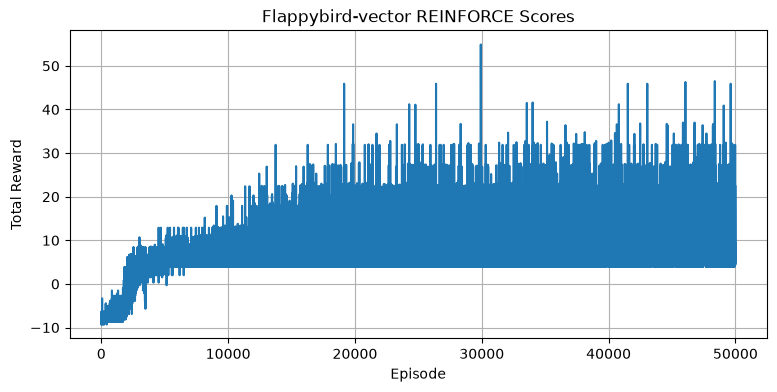

In [14]:
plt.figure(figsize=(9, 4))
plt.plot(scores)
plt.title("Flappybird-vector REINFORCE Scores")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

In [15]:
def evaluate_agent(env, max_steps, n_eval_episodes, policy):
    """
    Evaluate the agent for ``n_eval_episodes`` episodes and returns average reward and std of reward.
    :param env: The evaluation environment
    :param max_steps: Maximum steps per episode
    :param n_eval_episodes: Number of episodes to evaluate the agent
    :param policy: The Reinforce agent
    """
    episode_rewards = []
    for episode in range(n_eval_episodes):
        # Gymnasium reset returns (state, info)
        state, _ = env.reset()
        done = False
        total_rewards_ep = 0

        for step in range(max_steps):
            action, _ = policy.act(state)
            
            # Gymnasium step returns 5 values: state, reward, terminated, truncated, info
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            total_rewards_ep += reward

            if done:
                break
        episode_rewards.append(total_rewards_ep)
        
    mean_reward = np.mean(episode_rewards)
    std_reward = np.std(episode_rewards)

    return mean_reward, std_reward

In [16]:
evaluate_agent(
    eval_env, hyperparameters["max_t"], hyperparameters["n_evaluation_episodes"], policy
)

(np.float64(9.709999999999994), np.float64(4.410770907675897))

### Push to the Hub

In [17]:
from huggingface_hub import HfApi, snapshot_download
from huggingface_hub.repocard import metadata_eval_result, metadata_save

from pathlib import Path
import datetime
import json
import imageio

import tempfile

import os

In [18]:
def record_video(env, policy, out_directory, fps=30):
    images = []  
    done = False
    state, info = env.reset()
    
    # Gymnasium returns the frame directly when render_mode="rgb_array" is set on env creation
    img = env.render()
    images.append(img)
    
    while not done:
        action, _ = policy.act(state)
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        img = env.render()
        images.append(img)
        
    imageio.mimsave(out_directory, [np.array(img) for img in images], fps=fps)

In [19]:
def push_to_hub(repo_id,
                model,
                hyperparameters,
                eval_env,
                video_fps=30
                ):
  """
  Evaluate, Generate a video and Upload a model to Hugging Face Hub.
  This method does the complete pipeline:
  - It evaluates the model
  - It generates the model card
  - It generates a replay video of the agent
  - It pushes everything to the Hub

  :param repo_id: repo_id: id of the model repository from the Hugging Face Hub
  :param model: the pytorch model we want to save
  :param hyperparameters: training hyperparameters
  :param eval_env: evaluation environment
  :param video_fps: how many frame per seconds to record our video replay
  """

  _, repo_name = repo_id.split("/")
  api = HfApi()

  # Step 1: Create the repo
  repo_url = api.create_repo(
        repo_id=repo_id,
        exist_ok=True,
  )

  with tempfile.TemporaryDirectory() as tmpdirname:
    local_directory = Path(tmpdirname)

    # Step 2: Save the model
    torch.save(model, local_directory / "model.pt")

    # Step 3: Save the hyperparameters to JSON
    with open(local_directory / "hyperparameters.json", "w") as outfile:
      json.dump(hyperparameters, outfile)

    # Step 4: Evaluate the model and build JSON
    mean_reward, std_reward = evaluate_agent(eval_env,
                                            hyperparameters["max_t"],
                                            hyperparameters["n_evaluation_episodes"],
                                            model)
    # Get datetime
    eval_datetime = datetime.datetime.now()
    eval_form_datetime = eval_datetime.isoformat()

    evaluate_data = {
          "env_id": hyperparameters["env_id"],
          "mean_reward": mean_reward,
          "n_evaluation_episodes": hyperparameters["n_evaluation_episodes"],
          "eval_datetime": eval_form_datetime,
    }

    # Write a JSON file
    with open(local_directory / "results.json", "w") as outfile:
        json.dump(evaluate_data, outfile)

    # Step 5: Create the model card
    env_name = hyperparameters["env_id"]

    metadata = {}
    metadata["tags"] = [
          env_name,
          "reinforce",
          "reinforcement-learning",
          "custom-implementation",
          "deep-rl-class"
      ]

    # Add metrics
    eval = metadata_eval_result(
        model_pretty_name=repo_name,
        task_pretty_name="reinforcement-learning",
        task_id="reinforcement-learning",
        metrics_pretty_name="mean_reward",
        metrics_id="mean_reward",
        metrics_value=f"{mean_reward:.2f} +/- {std_reward:.2f}",
        dataset_pretty_name=env_name,
        dataset_id=env_name,
      )

    # Merges both dictionaries
    metadata = {**metadata, **eval}

    model_card = f"""
  # **Reinforce** Agent playing **{env_id}**
  This is a trained model of a **Reinforce** agent playing **{env_id}** .
  To learn to use this model and train yours check Unit 4 of the Deep Reinforcement Learning Course: https://huggingface.co/deep-rl-course/unit4/introduction
  """

    readme_path = local_directory / "README.md"
    readme = ""
    if readme_path.exists():
        with readme_path.open("r", encoding="utf8") as f:
          readme = f.read()
    else:
      readme = model_card

    with readme_path.open("w", encoding="utf-8") as f:
      f.write(readme)

    # Save our metrics to Readme metadata
    metadata_save(readme_path, metadata)

    # Step 6: Record a video
    video_path =  local_directory / "replay.mp4"
    record_video(env, model, video_path, video_fps)

    # Step 7. Push everything to the Hub
    api.upload_folder(
          repo_id=repo_id,
          folder_path=local_directory,
          path_in_repo=".",
    )

    print(f"Your model is pushed to the Hub. You can view your model here: {repo_url}")

In [23]:
repo_id = "eclatt/Reinforce-flappybird-v0-vector"  # TODO Define your repo id {username/Reinforce-{model-id}}
push_to_hub(
    repo_id,
    policy,  # The model we want to save
    hyperparameters,  # Hyperparameters
    eval_env,  # Evaluation environment
    video_fps=30
)

Your model is pushed to the Hub. You can view your model here: https://huggingface.co/eclatt/Reinforce-flappybird-v0-vector
